# Word2vec exercise
v2025

In [1]:
import re
import nltk
nltk.download('wordnet')
from sklearn import feature_extraction
stop_words = feature_extraction.text.ENGLISH_STOP_WORDS
# from nltk.stem import PorterStemmer
# from nltk.stem import WordNetLemmatizer
import numpy
import spacy

nlp = spacy.load("en_core_web_sm", disable=['parser', # 'tagger',
                                            'ner'])

print(stop_words)

[nltk_data] Downloading package wordnet to /Users/piyush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/Users/piyush/workspace/projects/DeepLearning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


frozenset({'always', 'besides', 'least', 'also', 'was', 'several', 'de', 'one', 'back', 'inc', 'only', 'you', 'before', 'yours', 'with', 'there', 'most', 'do', 'whereas', 'anyway', 'his', 'behind', 'hundred', 'rather', 'or', 'by', 'yourself', 'against', 're', 'latter', 'me', 'somewhere', 'whenever', 'those', 'were', 'fill', 'down', 'i', 'am', 'wherein', 'since', 'seem', 'hasnt', 'top', 'onto', 'made', 'such', 'never', 'due', 'whether', 'as', 'still', 'empty', 'side', 'its', 'although', 'some', 'thence', 'then', 'themselves', 'already', 'noone', 'not', 'been', 'serious', 'first', 'found', 'if', 'give', 'but', 'here', 'else', 'could', 'others', 'whence', 'between', 'latterly', 'everywhere', 'whither', 'off', 'seeming', 'thereupon', 'thus', 'whatever', 'formerly', 'un', 'sixty', 'that', 'nowhere', 'whose', 'otherwise', 'ours', 'thick', 'even', 'being', 'had', 'ten', 'per', 'are', 'front', 'six', 'nine', 'all', 'less', 'co', 'towards', 'is', 'have', 'find', 'might', 'few', 'at', 'more', 'a

In [2]:
# def preprocess(text):
#   text = text.lower() #lowercase
#   text = re.sub(r'[^\w\s]', '', text) #remove punctuations
#   text = re.sub(r'\d+', '', text) #remove numbers
#   text = " ".join(text.split()) #stripWhitespace
#   text = text.split()
#   text = [x for x in text if x not in stop_words] #remove stopwords
#   text = " ".join(text)

#   tokens = nlp(text)

#   lemma_list = []
#   for word in tokens:
#     #token_list.append(token.text)
#     lemma = word.lemma_.strip()
#     lemma_list.append(lemma)
#   #token_list
#   text = " ".join(lemma_list)
#   # print(text)
#   return(text)

def preprocess(text):
    text = re.sub(r'[^\w\s]', '', text.lower())  # Lowercase & remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = " ".join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    
    return " ".join([word.lemma_.strip() for word in nlp(text)])  # Lemmatization

In [3]:
text = 'ChatGPT: Optimizing Language Models for'
preprocess(text)

'chatgpt optimize language model'


---

## Data: [ChatGPT sentiment analysis](https://www.kaggle.com/datasets/charunisa/chatgpt-sentiment-analysis?resource=download)

ChatGPT has been a major talk in the tech world. The tweets about chatgpt were gathered for a month and then the sentiment analysis was made using Natural Language Processing.

In [4]:
import pandas as pd
data = pd.read_csv("/Users/piyush/workspace/projects/DeepLearning/week5/ChatGPT_sentiment_txt.csv", index_col = 0)

In [5]:
data.head()

,tweets,labels
0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,"Try talking with ChatGPT, our new AI system wh...",good
2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,"THRILLED to share that ChatGPT, our new model ...",good
4,"As of 2 minutes ago, @OpenAI released their ne...",bad


In [6]:
print(data.shape)

(219294, 2)


In [7]:
data = data.rename(columns={'tweets': 'text'})

In [8]:
from datetime import datetime

print(datetime.now())
data['text_processed'] = data['text'].apply(lambda x:preprocess(x))
print(datetime.now())

2025-03-05 20:27:38.396024
2025-03-05 20:32:37.860170


In [9]:
data.to_csv('/Users/piyush/workspace/projects/DeepLearning/week5/ChatGPT_sentiment_txt_processed.csv')


In [10]:
data['text_processed'] = data['text_processed'].apply(lambda x:x.split())

In [11]:
data.head()

,text,labels,text_processed
0,ChatGPT: Optimizing Language Models for Dialog...,neutral,"[chatgpt, optimize, language, model, dialogue,..."
1,"Try talking with ChatGPT, our new AI system wh...",good,"[try, talk, chatgpt, new, ai, optimize, dialog..."
2,ChatGPT: Optimizing Language Models for Dialog...,neutral,"[chatgpt, optimize, language, model, dialogue,..."
3,"THRILLED to share that ChatGPT, our new model ...",good,"[thrill, share, chatgpt, new, model, optimize,..."
4,"As of 2 minutes ago, @OpenAI released their ne...",bad,"[minute, ago, openai, release, new, chatgpt, n..."


In [12]:
data

,text,labels,text_processed
0,ChatGPT: Optimizing Language Models for Dialog...,neutral,"[chatgpt, optimize, language, model, dialogue,..."
1,"Try talking with ChatGPT, our new AI system wh...",good,"[try, talk, chatgpt, new, ai, optimize, dialog..."
2,ChatGPT: Optimizing Language Models for Dialog...,neutral,"[chatgpt, optimize, language, model, dialogue,..."
3,"THRILLED to share that ChatGPT, our new model ...",good,"[thrill, share, chatgpt, new, model, optimize,..."
4,"As of 2 minutes ago, @OpenAI released their ne...",bad,"[minute, ago, openai, release, new, chatgpt, n..."
...,...,...,...
219289,Other Software Projects Are Now Trying to Repl...,bad,"[software, project, try, replicate, chatgpt, h..."
219290,I asked #ChatGPT to write a #NYE Joke for SEOs...,good,"[ask, chatgpt, write, nye, joke, seo, deliver,..."
219291,chatgpt is being disassembled until it can onl...,bad,"[chatgpt, disassemble, dissemble]"
219292,2023 predictions by #chatGPT. Nothing really s...,bad,"[prediction, chatgpt, really, specific, just, ..."


In [13]:
from gensim.models import Word2Vec

print(datetime.now())
model = Word2Vec(sentences=data['text_processed'].tolist(), vector_size=100, sg=1,min_count=5,window=5,workers=50,seed=10,epochs=50)
print(datetime.now())
#vector_size (int, optional) – Dimensionality of the word vectors.
#min_count (int, optional) – Ignores all words with total frequency lower than this.
#window (int, optional) – Maximum distance between the current and predicted word within a sentence.
#workers (int, optional) – Use these many worker threads to train the model (=faster training with multicore machines).
#sg ({0, 1}, optional) – Training algorithm: 1 for skip-gram; otherwise CBOW.
#epochs (int, optional) – Number of iterations (epochs) over the corpus. (Formerly: iter)

#The meaning of most of the parameters are beyond the scope of this class. If interested, please check the official documentations: https://radimrehurek.com/gensim/models/word2vec.html

2025-03-05 20:32:38.992798
2025-03-05 20:33:50.451612


Be patient! This took ~10min for worker=50, ~9min for worker=25.

Replace the 210k data with a smaller one if you encounter errors for multiple times!! (or increase min_count, or decrease vector_size, or decrease window, or decrease epochs)



In [14]:
model.save('/Users/piyush/workspace/projects/DeepLearning/week5/w2v_dr.w2v')


In [15]:
model=Word2Vec.load('/Users/piyush/workspace/projects/DeepLearning/week5/w2v_dr.w2v')

In [16]:
vocab = model.wv.index_to_key

In [17]:
len(vocab)

19353

In [18]:
# find the top 10 most similar vector to *chatgpt*
model.wv.most_similar('chatgpt', topn=10)

[('ai', 0.7366155982017517),
 ('just', 0.6170478463172913),
 ('openai', 0.598831832408905),
 ('nni', 0.586150050163269),
 ('httpstcotethqxvit', 0.5646928548812866),
 ('httpstconuxptvmz', 0.5627025365829468),
 ('nnchatgpt', 0.5507106184959412),
 ('httpstcohvlvtypr', 0.5452831983566284),
 ('httpstcobkcvgbry', 0.5451473593711853),
 ('httpstcoxxknvatd', 0.5436145067214966)]

In [19]:
# find the top 10 most similar vector to *ai*
model.wv.most_similar('ai', topn=10)

[('chatgpt', 0.7366157174110413),
 ('enterpriseai', 0.6395758986473083),
 ('httpstcocdsftzvjz', 0.6274704337120056),
 ('nnai', 0.6188498735427856),
 ('artificialintelligence', 0.6105139851570129),
 ('httpstcotevysjhjr', 0.597664475440979),
 ('businessanalytic', 0.5965616703033447),
 ('cnetnnread', 0.5920212268829346),
 ('rtforbestech', 0.5895208716392517),
 ('digitalization', 0.584997832775116)]

In [20]:
v_time = model.wv['time']

In [21]:
v_time

array([ 0.0384506 ,  0.09117808, -0.17099671,  0.2819714 ,  0.3230253 ,
        0.07775431, -0.32037565,  0.15747237, -0.08168484, -0.09522977,
       -0.06037627,  0.10387895, -0.15182677,  0.256033  , -0.11333305,
        0.1557552 , -0.06070878, -0.31435326, -0.01123621,  0.3896499 ,
        0.01141471,  0.17499115,  0.22420098,  0.08464667, -0.39150995,
       -0.12186874,  0.25047544,  0.03940287, -0.02865851,  0.13164243,
       -0.19421689, -0.16652985, -0.32839286,  0.25128046, -0.21323945,
       -0.04830623,  0.29122773, -0.04058351,  0.22364351,  0.33273286,
        0.02519596,  0.01658542,  0.26395446,  0.30838218, -0.2106354 ,
        0.15804796,  0.20554285, -0.38590905, -0.14867537, -0.02853505,
        0.08441275,  0.21456891, -0.24525505, -0.02324162, -0.4811532 ,
        0.25664398,  0.26709235, -0.0579109 ,  0.08495625, -0.01900091,
        0.06177287, -0.12039186, -0.11224969,  0.0075932 , -0.0129937 ,
        0.42881027,  0.1911691 ,  0.0295744 ,  0.17296591,  0.19

## Calculate the similarity
- Here are some examples

In [22]:
model.wv.similarity('chatgpt', 'ai')

0.7366156

In [23]:
model.wv.similarity('chatgpt', 'fake')

0.25381756

In [24]:
model.wv.similarity('chatgpt', 'trust')

0.21480337

In [25]:
model.wv.similarity('openai', 'chatgpt')

0.59883183

In [26]:
model.wv.similarity('chatgpt', 'chatbot')

0.44948417

In [27]:
model.wv.similarity('chatgpt', 'finance')

0.23850968

In [28]:
v_finance = model.wv['finance']
v_chatgpt = model.wv['chatgpt']
numpy.dot(v_finance, v_chatgpt)/(numpy.linalg.norm(v_finance)* numpy.linalg.norm(v_chatgpt))


0.2385097

In [29]:
v_1 = model.wv['finance']
v_2 = model.wv['revenue']
numpy.dot(v_1, v_2)/(numpy.linalg.norm(v_1)* numpy.linalg.norm(v_2))


0.12172182

In [30]:
v_1 = model.wv['chatgpt']
v_2 = model.wv['openai']
numpy.dot(v_1, v_2)/(numpy.linalg.norm(v_1)* numpy.linalg.norm(v_2))

0.59883183

In [31]:
v_1 = model.wv['chatgpt']
v_2 = model.wv['tesla']
numpy.dot(v_1, v_2)/(numpy.linalg.norm(v_1)* numpy.linalg.norm(v_2))

0.21292974

In [32]:
v_1 = model.wv['king']
v_2 = model.wv['queen']
v_3 = model.wv['man']
v_4 = model.wv['woman']
v_new = v_1 - v_3 + v_4

numpy.dot(v_new, v_2)/(numpy.linalg.norm(v_new)* numpy.linalg.norm(v_2))



0.38306805

## Now try it on by yourself!
Select those vectors that you are interested in and use the above code to calculate the similarity.



---



## Model Results

In [33]:
model.wv.vectors.shape

(19353, 100)

In [34]:
outdata=pd.DataFrame(model.wv.vectors)

In [35]:
outdata

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.005449,0.002317,-0.194089,0.287834,0.217506,0.230784,-0.019005,-0.074018,0.128699,-0.068474,...,0.018818,-0.193272,-0.033588,0.243102,0.078185,-0.008194,-0.134087,-0.289216,-0.102063,-0.132724
1,0.286862,-0.117584,0.025005,0.020271,0.236526,0.153549,-0.261801,-0.017394,0.029073,0.150659,...,0.109194,-0.109779,0.008095,0.342974,-0.060807,-0.055002,-0.059626,-0.570513,-0.119650,-0.326152
2,-0.090659,-0.037640,-0.339969,0.204029,0.164261,-0.146553,0.001623,-0.200812,-0.082845,-0.016022,...,-0.045314,0.126818,-0.341924,-0.022240,0.009705,-0.159581,-0.169498,-0.371242,0.020791,0.002152
3,-0.133907,-0.212044,-0.073097,0.026644,0.393465,-0.312976,0.041521,-0.245600,0.163921,-0.132843,...,-0.112112,-0.143950,-0.193458,0.265801,0.183650,0.173055,0.234693,-0.501293,-0.051991,-0.142935
4,-0.300165,-0.134285,-0.245670,0.109531,0.045282,-0.260407,-0.051984,-0.364457,0.329848,-0.134512,...,-0.226719,-0.086360,-0.206633,0.269702,-0.035578,-0.004395,-0.104340,-0.198821,-0.155114,-0.000501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19348,0.119048,0.563324,-0.325250,-0.021430,0.447406,0.601599,0.170084,-0.184636,0.008660,-0.508941,...,0.208500,0.406974,0.194094,0.084997,-0.953337,-0.125458,0.049521,-0.156437,0.187262,0.847783
19349,-0.319691,-0.255033,-1.031336,0.687318,-0.124509,0.181210,0.248171,-0.068052,-0.095007,-0.531786,...,-0.714183,0.220831,-0.060423,0.054228,-0.253114,-0.417374,0.210935,0.230375,0.035394,-0.121344
19350,-0.268936,0.016578,-0.411592,-0.561749,0.702838,-0.394989,0.116960,-0.919979,0.055219,-0.262100,...,0.146514,-0.890916,0.125228,-0.553204,-0.807770,0.657447,0.236326,-0.651460,0.208392,0.387384
19351,-0.239391,0.386173,0.293153,0.756261,0.438928,-0.651637,0.056172,-0.705142,0.095911,0.182925,...,-0.005997,-0.482313,-0.322956,0.133451,0.397748,0.309126,-0.298933,0.307859,-0.371584,0.183149


## Save the .tsv file below and upload them on the [Projector](https://projector.tensorflow.org/) for visulization


In [36]:
outdata.to_csv('/Users/piyush/workspace/projects/DeepLearning/week5/word2vec_chatgpt.tsv',sep='\t',index=False,header=False)

In [37]:
pd.DataFrame(model.wv.index_to_key).to_csv('/Users/piyush/workspace/projects/DeepLearning/week5/word2vec_chatgpt_words.tsv',sep='\t',index=False,header=False)

These two files can be found in your Colab "Files" folder, as shown in the red circle below:

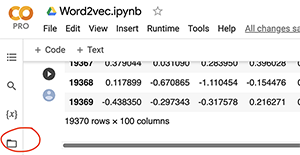

[x] Use the **Load** button to upload both .tsv files you downloaded. The first file is word2vec_chatgpt.tsv, and the second file is word2vec_chatgpt_words.tsv.

Please be aware that it shows the distance of two vectors. Therefore, the smaller the number, the more similar the two words are.

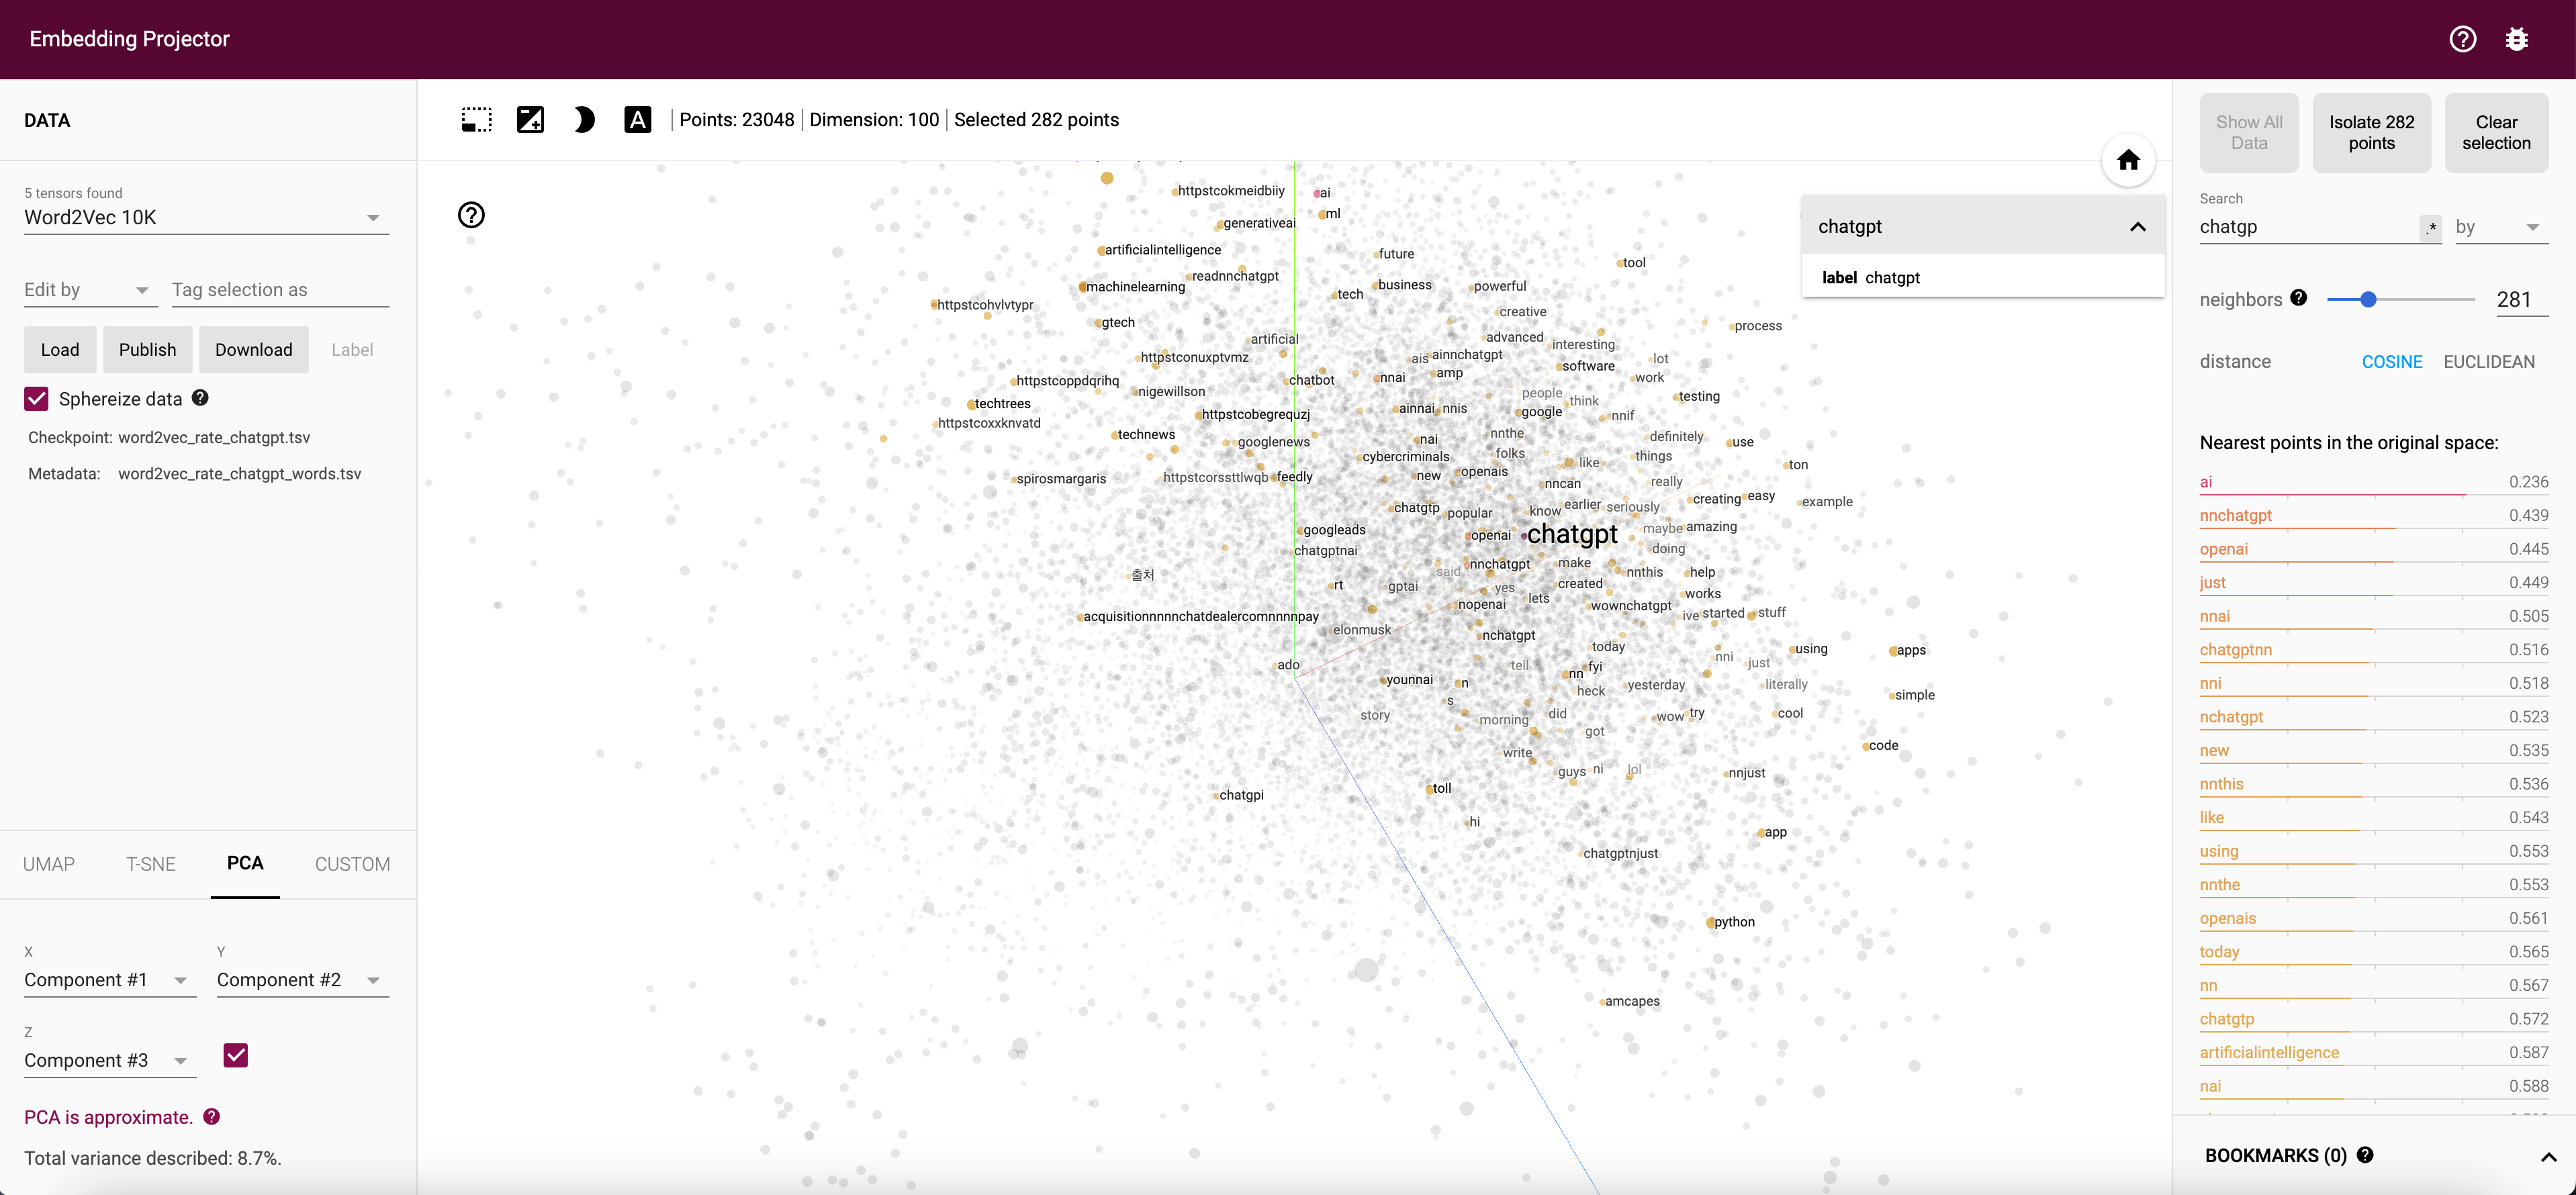